# Статистическая валидация результатов факторных стратегий

**Автор:** Еремкин Дмитрий Валерьевич
**Магистерская программа:** «Инвестиции на финансовых рынках», НИУ ВШЭ, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eremkindv91/dividend-factor-strategies/blob/main/notebooks/05_statistical_validation.ipynb)

---

Ноутбук формально проверяет результаты бэктеста (ноутбуки 01–02) и отвечает на три вопроса,
которые обычно задаёт комиссия:

1. **Значимость.** Превышение коэффициента Шарпа стратегии над индексом — это статистически
   значимо или случайность? → тесты Jobson–Korkie/Memmel и Ledoit–Wolf.
2. **Надёжность.** Насколько устойчивы оценки на ~160 месячных наблюдениях? → блочный бутстрэп.
3. **Data mining.** Не выбраны ли «лучшие» дескрипторы случайно из-за перебора десятков
   факторов? → поправки Harvey–Liu–Zhu и Benjamini–Hochberg.

Предварительный блок проверяет качество рядов доходностей (нормальность, кластеризация
волатильности, стационарность) — он обосновывает применение робастных (HAC) ошибок и бутстрэпа.

### Академические источники
- Jobson & Korkie (1981); Memmel (2003) — тест равенства коэффициентов Шарпа
- Ledoit & Wolf (2008) — *Robust performance hypothesis testing with the Sharpe ratio*
- Newey & West (1987) — HAC-оценка ковариации
- Politis & Romano (1992) — circular block bootstrap
- Harvey, Liu & Zhu (2016) — *…and the Cross-Section of Expected Returns*
- Benjamini & Hochberg (1995) — контроль доли ложных открытий (FDR)

In [1]:
# ─── Setup: окружение и пути (Colab / локально) ───────────────────────
import os, sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

if 'google.colab' in sys.modules:
    REPO_URL = "https://github.com/eremkindv91/dividend-factor-strategies"
    if not os.path.exists("/content/dividend-factor-strategies"):
        os.system(f"git clone {REPO_URL} /content/dividend-factor-strategies")
    PROJECT_ROOT = Path("/content/dividend-factor-strategies")
    os.chdir(PROJECT_ROOT); sys.path.insert(0, str(PROJECT_ROOT))
else:
    PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())

DATA_DIR = PROJECT_ROOT / "data"
RESULTS  = PROJECT_ROOT / "results"
OUT      = RESULTS / "stat_validation"; OUT.mkdir(parents=True, exist_ok=True)
print("Project:", PROJECT_ROOT.name)
print("Results:", RESULTS)

Project: dividend-factor-strategies
Results: /Users/dmitrijeremkin/dividend-factor-strategies/results


In [2]:
import warnings; warnings.simplefilter('ignore')
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss

SEED   = 42            # фиксируем для воспроизводимости
ANN    = np.sqrt(12)   # годовой множитель Шарпа (месячные данные)
N_BOOT = 5000
BLOCK  = 6
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans',
                     'axes.grid': True, 'grid.alpha': 0.3})
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

## 1. Данные и обозначения

Вход — **месячные доходности портфелей** (в долях) из бэктеста (ноутбуки 01–02), сохранённые в
`results/factor_backtest/monthly_returns.xlsx` (листы `Russia` и `Japan`). На каждом рынке:

- **классические факторы** (long-only, top-N, equal-weight): `Value, Size, Momentum, LowVol,
  Liquidity, Dividend, Quality`;
- **декомпозиция Quality**: `Q0` (baseline), `Q1` (profitability), `Q2` (payout/CF),
  `Q3` (market-specific);
- **факторы Fama–French** (long-only): `FF_SMB≈Size, FF_HML≈Value, FF_RMW≈Profitability,
  FF_WML≈Momentum, FF_CMA≈Investment`;
- **`Benchmark_TR`** — индекс полной доходности (MCFTR для РФ, Nikkei 225 TR для Японии);
- **`rf_m`** — месячная безрисковая ставка (RUONIA для РФ; краткосрочная ставка для Японии).

Избыточная доходность считается помесячно: `e = r − rf_m`. Годовой коэффициент Шарпа =
месячный × √12. Каждый парный тест «стратегия vs индекс» считается на пересечении непустых
наблюдений (часть рядов стартует позже).

In [3]:
MR_PATH = RESULTS / "factor_backtest" / "monthly_returns.xlsx"

def load_market(sheet):
    df = pd.read_excel(MR_PATH, sheet_name=sheet, index_col=0, parse_dates=True)
    rf = df.pop('rf_m')
    bench = 'Benchmark_TR'
    strategies = [c for c in df.columns if c != bench]
    return df, rf, bench, strategies

MARKETS = {
    'Россия (MOEX)':       dict(zip(['r','rf','bench','strat'], load_market('Russia'))),
    'Япония (Nikkei 225)': dict(zip(['r','rf','bench','strat'], load_market('Japan'))),
}
for name, m in MARKETS.items():
    print(f"{name}: {len(m['strat'])} стратегий + индекс, {len(m['r'])} мес. "
          f"[{m['r'].index.min():%Y-%m} … {m['r'].index.max():%Y-%m}], "
          f"rf≈{m['rf'].mean()*12:.2%} год.")

Россия (MOEX): 16 стратегий + индекс, 164 мес. [2012-05 … 2025-12], rf≈9.35% год.
Япония (Nikkei 225): 16 стратегий + индекс, 162 мес. [2012-07 … 2025-12], rf≈0.09% год.


## 2. Качество рядов доходностей

Перед содержательными тестами проверяем три свойства рядов:

| Тест | Гипотеза H₀ | Что означает отклонение |
|---|---|---|
| **Jarque–Bera** | доходности нормальны | «тяжёлые хвосты» → бутстрэп и просадка вместо опоры только на Шарп |
| **Ljung–Box** (на квадратах, 12 лагов) | нет автокорреляции квадратов | кластеризация волатильности (ARCH) → нужны HAC-ошибки |
| **ADF** + **KPSS** | (ADF) единичный корень / (KPSS) стационарность | стационарность ряда → корректны t-тесты и бутстрэп |

Вывод «стационарен», если ADF отвергает единичный корень (**p < 0.05**) **и** статистика KPSS
ниже 5%-критического значения (тогда H₀ о стационарности не отвергается).

> **Примечание по KPSS.** В `statsmodels` p-value KPSS ограничен сверху уровнем 0.10 (когда
> статистика ниже табличного диапазона, возвращается ровно 0.10). Поэтому в таблице приводим
> **саму статистику KPSS и 5%-критическое значение** (≈0.463 для спецификации с константой) и
> сравниваем их напрямую, а не округлённый p.

In [4]:
def step2_quality(r):
    rows = []
    for col in r.columns:
        x = r[col].dropna()
        jb_p  = stats.jarque_bera(x)[1]
        lb_p  = acorr_ljungbox(x.values**2, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
        adf_p = adfuller(x.values, autolag='AIC')[1]
        # KPSS: показываем САМУ статистику и 5%-крит. значение (p в statsmodels
        # ограничен сверху 0.10, когда статистика вне таблицы — отсюда мнимая
        # «одинаковость»; решаем по сравнению статистики с крит. значением).
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                kstat, _, _, kcrit = kpss(x.values, regression='c', nlags='auto')
                kcrit5 = kcrit['5%']
            except Exception:
                kstat, kcrit5 = np.nan, np.nan
        # H0 KPSS = стационарность: НЕ отвергаем, если статистика < 5%-крит.
        stationary = (adf_p < 0.05) and (kstat < kcrit5)
        rows.append({'Ряд': col, 'N': len(x),
                     'JB p': jb_p, 'Тяжёлые хвосты': 'да' if jb_p < 0.05 else 'нет',
                     'LB p': lb_p, 'Кластеризация': 'да' if lb_p < 0.05 else 'нет',
                     'ADF p': adf_p, 'KPSS стат.': kstat, 'KPSS 5%крит.': kcrit5,
                     'Стационарен': 'да' if stationary else 'проверить'})
    return pd.DataFrame(rows)

quality = {}
for name, m in MARKETS.items():
    q = step2_quality(m['r'])          # m['r'] уже включает Benchmark_TR
    quality[name] = q
    n = len(q)
    print(f"\n### {name}: тяжёлые хвосты {sum(q['Тяжёлые хвосты']=='да')}/{n}, "
          f"кластеризация {sum(q['Кластеризация']=='да')}/{n}, "
          f"стационарны {sum(q['Стационарен']=='да')}/{n}")
    display(q.round(3))


### Россия (MOEX): тяжёлые хвосты 17/17, кластеризация 13/17, стационарны 17/17


,Ряд,N,JB p,Тяжёлые хвосты,LB p,Кластеризация,ADF p,KPSS стат.,KPSS 5%крит.,Стационарен
0,Value,164,0.000,да,0.036,да,0.000,0.099,0.463,да
1,Size,160,0.000,да,0.000,да,0.000,0.125,0.463,да
2,Momentum,164,0.001,да,0.000,да,0.000,0.075,0.463,да
3,LowVol,164,0.000,да,0.000,да,0.000,0.103,0.463,да
4,Liquidity,128,0.000,да,0.014,да,0.000,0.079,0.463,да
5,Dividend,164,0.000,да,0.000,да,0.000,0.050,0.463,да
6,Quality,164,0.000,да,0.000,да,0.000,0.074,0.463,да
7,Q0,164,0.000,да,0.000,да,0.008,0.074,0.463,да
8,Q1,164,0.000,да,0.000,да,0.000,0.082,0.463,да
9,Q2,164,0.000,да,0.001,да,0.000,0.049,0.463,да



### Япония (Nikkei 225): тяжёлые хвосты 7/17, кластеризация 7/17, стационарны 17/17


,Ряд,N,JB p,Тяжёлые хвосты,LB p,Кластеризация,ADF p,KPSS стат.,KPSS 5%крит.,Стационарен
0,Value,162,0.220,нет,0.002,да,0.000,0.129,0.463,да
1,Size,162,0.053,нет,0.012,да,0.000,0.117,0.463,да
2,Momentum,162,0.030,да,0.452,нет,0.000,0.074,0.463,да
3,LowVol,162,0.005,да,0.002,да,0.000,0.184,0.463,да
4,Liquidity,162,0.004,да,0.038,да,0.000,0.164,0.463,да
5,Dividend,162,0.377,нет,0.032,да,0.000,0.172,0.463,да
6,Quality,162,0.151,нет,0.842,нет,0.000,0.091,0.463,да
7,Q0,162,0.430,нет,0.894,нет,0.000,0.101,0.463,да
8,Q1,162,0.248,нет,0.956,нет,0.000,0.079,0.463,да
9,Q2,162,0.133,нет,0.177,нет,0.000,0.262,0.463,да


**Интерпретация.** Тяжёлые хвосты и кластеризация волатильности типичны для финансовых
рядов — это не ошибка данных, а основание применять робастные (HAC) ошибки Ньюи–Уэста и
бутстрэп, а риск измерять в т.ч. максимальной просадкой, а не только коэффициентом Шарпа.
Стационарность рядов доходностей подтверждает корректность последующих t-тестов и бутстрэпа.

## 3. Значимость превышения Шарпа над индексом

H₀: коэффициент Шарпа стратегии равен коэффициенту Шарпа индекса. Тесты — на месячных
избыточных доходностях `e = r − rf_m`.

**3.1. Jobson–Korkie с поправкой Memmel (2003)** — классический тест. На месячных
`sr_i = mean(e_i)/std(e_i)`:
$$\theta=\tfrac1T\big[\,2(1-\rho)+\tfrac12(sr_1^2+sr_2^2)-sr_1 sr_2\,\rho^2\big],\qquad
z=\frac{sr_1-sr_2}{\sqrt{\theta}}.$$

**3.2. Ledoit–Wolf (2008), HAC** — устойчив к ненормальности и автокорреляции (которые
показал блок 2). Разница Шарпов параметризуется через четыре момента, ковариация моментных
функций оценивается HAC-методом Ньюи–Уэста (бартлеттовские веса, $L=\lfloor 4(T/100)^{2/9}\rfloor$),
градиент — численно. **В работу выносится LW-версия**, JK–Memmel — как отправная точка.

In [5]:
def jk_memmel(e1, e2):
    m = ~(np.isnan(e1) | np.isnan(e2)); a, b = e1[m], e2[m]; T = len(a)
    sr1, sr2 = a.mean()/a.std(ddof=1), b.mean()/b.std(ddof=1)
    rho = np.corrcoef(a, b)[0, 1]
    theta = (1/T) * (2*(1-rho) + 0.5*(sr1**2+sr2**2) - sr1*sr2*rho**2)
    if theta <= 0: return sr1, sr2, np.nan, np.nan
    z = (sr1-sr2)/np.sqrt(theta)
    return sr1, sr2, z, 2*(1-stats.norm.cdf(abs(z)))

def _nw_cov(G, L):
    T = G.shape[0]; Gc = G - G.mean(0); S = (Gc.T @ Gc)/T
    for l in range(1, L+1):
        w = 1 - l/(L+1); Gl = (Gc[l:].T @ Gc[:-l])/T; S += w*(Gl+Gl.T)
    return S

def ledoit_wolf_hac(e1, e2):
    m = ~(np.isnan(e1) | np.isnan(e2)); a, b = e1[m], e2[m]; T = len(a)
    mu1, mu2 = a.mean(), b.mean(); q1, q2 = (a**2).mean(), (b**2).mean()
    f = lambda m1, m2, Q1, Q2: m1/np.sqrt(Q1-m1**2) - m2/np.sqrt(Q2-m2**2)
    val = f(mu1, mu2, q1, q2)
    G = np.column_stack([a-mu1, b-mu2, a**2-q1, b**2-q2])
    L = int(np.floor(4*(T/100)**(2/9))); S = _nw_cov(G, L)
    th = np.array([mu1, mu2, q1, q2], float); grad = np.zeros(4)
    for i in range(4):
        h = 1e-6*max(1.0, abs(th[i])); tp = th.copy(); tm = th.copy(); tp[i]+=h; tm[i]-=h
        grad[i] = (f(*tp)-f(*tm))/(2*h)
    var = grad @ S @ grad / T
    if var <= 0: return val, np.nan, np.nan
    z = val/np.sqrt(var)
    return val, z, 2*(1-stats.norm.cdf(abs(z)))

def step3(m):
    r, rf, bench, strat = m['r'], m['rf'], m['bench'], m['strat']
    eb = (r[bench]-rf).values; rows = []
    for s in strat:
        es = (r[s]-rf).values
        sr1, sr2, jkz, jkp = jk_memmel(es, eb)
        _, lwz, lwp = ledoit_wolf_hac(es, eb)
        rows.append({'Стратегия': s, 'Sharpe стратегии': sr1*ANN, 'Sharpe индекса': sr2*ANN,
                     'JK z': jkz, 'JK p': jkp, 'LW z': lwz, 'LW p': lwp,
                     'Значимо 5% (LW)': 'да' if (pd.notna(lwp) and lwp < 0.05) else 'нет'})
    return (pd.DataFrame(rows)
            .sort_values('Sharpe стратегии', ascending=False).reset_index(drop=True))

sharpe = {}
for name, m in MARKETS.items():
    s3 = step3(m); sharpe[name] = s3
    win = s3[s3['Значимо 5% (LW)']=='да']['Стратегия'].tolist()
    print(f"\n### {name} — значимо обыгрывают индекс (LW 5%): {win if win else '—'}")
    display(s3.round(3))


### Россия (MOEX) — значимо обыгрывают индекс (LW 5%): —


,Стратегия,Sharpe стратегии,Sharpe индекса,JK z,JK p,LW z,LW p,Значимо 5% (LW)
0,Q3,0.457,0.179,1.888,0.059,1.776,0.076,нет
1,FF_RMW,0.457,0.222,1.445,0.148,1.554,0.120,нет
2,Q2,0.450,0.179,1.891,0.059,1.656,0.098,нет
3,Dividend,0.407,0.179,1.514,0.130,1.319,0.187,нет
4,Size,0.387,0.240,0.648,0.517,0.714,0.475,нет
5,Value,0.328,0.179,0.843,0.399,0.783,0.434,нет
6,FF_SMB,0.309,0.179,0.518,0.604,0.604,0.546,нет
7,Momentum,0.242,0.179,0.338,0.735,0.323,0.746,нет
8,Liquidity,0.223,0.186,0.135,0.892,0.154,0.877,нет
9,LowVol,0.215,0.179,0.206,0.837,0.204,0.838,нет



### Япония (Nikkei 225) — значимо обыгрывают индекс (LW 5%): ['Q1']


,Стратегия,Sharpe стратегии,Sharpe индекса,JK z,JK p,LW z,LW p,Значимо 5% (LW)
0,Q1,1.211,0.955,1.783,0.075,2.027,0.043,да
1,Dividend,1.188,0.955,1.180,0.238,1.379,0.168,нет
2,Q0,1.183,0.955,1.618,0.106,1.806,0.071,нет
3,Quality,1.152,0.955,1.303,0.192,1.579,0.114,нет
4,FF_CMA,1.116,0.955,0.807,0.420,0.999,0.318,нет
5,Q3,1.103,0.955,0.933,0.351,1.391,0.164,нет
6,Liquidity,1.078,0.955,0.678,0.498,0.727,0.467,нет
7,LowVol,1.069,0.955,0.550,0.582,0.574,0.566,нет
8,Q2,1.052,0.955,0.520,0.603,0.603,0.546,нет
9,Size,1.025,0.955,0.354,0.723,0.375,0.708,нет


**Санити-проверка.** z по JK и LW одного знака и близкого масштаба во всех строках — реализация
корректна. Содержательно: на **российском** рынке ни одна стратегия не обыгрывает MCFTR значимо
на 5% (лучшие — payout/market-specific Quality, p≈0.08–0.10). На **японском** рынке значимо
превосходит Nikkei 225 TR profitability-Quality (`Q1`): Sharpe ≈ 1.21 против 0.95, LW p≈0.043.

## 4. Блочный бутстрэп (надёжность оценок)

Circular block bootstrap (Politis–Romano 1992) сохраняет автокорреляцию и кластеризацию
волатильности. **5000 репликаций, длина блока 6 месяцев.** Ключевой момент: индексы времени
ресэмплируются **один раз на репликацию** и применяются ко всем колонкам — это сохраняет
зависимость стратегии и индекса, без чего p-value разницы Шарпов был бы некорректен.

Для каждого ряда строим бутстрэп-распределение годового Шарпа и CAGR, выводим перцентили 2.5%
и 97.5%. Дополнительно — bootstrap p-value гипотезы `SR_strat ≤ SR_bench` (доля репликаций, где
стратегия не лучше индекса, на общих индексах).

In [6]:
def block_index_matrix(T, block, n_boot, rng):
    nb = int(np.ceil(T/block)); starts = rng.integers(0, T, size=(n_boot, nb))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]) % T
    return idx.reshape(n_boot, nb*block)[:, :T]

def _ann_sharpe(E):  # (n_boot, T)
    return np.nanmean(E, 1) / np.nanstd(E, 1, ddof=1) * ANN

def _cagr(R):
    with np.errstate(divide='ignore', invalid='ignore'):
        cnt = np.sum(~np.isnan(R), 1)
        return np.exp(np.nansum(np.log1p(R), 1) * 12.0/cnt) - 1.0

def step4(m, rng):
    r, rf, bench, strat = m['r'], m['rf'], m['bench'], m['strat']
    cols = list(r.columns); kB = cols.index(bench)
    R = r.values; E = r.sub(rf, axis=0).values
    idx = block_index_matrix(len(r), BLOCK, N_BOOT, rng)
    Eb_B = E[:, kB][idx]
    pt = lambda c: ((r[c]-rf).dropna().mean()/(r[c]-rf).dropna().std(ddof=1)*ANN)
    ptc = lambda c: np.prod(1+r[c].dropna().values)**(12/r[c].dropna().shape[0])-1
    rows, dists = [], {}
    for c in cols:
        k = cols.index(c); sh = _ann_sharpe(E[:, k][idx]); cg = _cagr(R[:, k][idx])
        dists[c] = sh
        row = {'Ряд': c, 'Sharpe': pt(c),
               'Sharpe 2.5%': np.nanpercentile(sh, 2.5), 'Sharpe 97.5%': np.nanpercentile(sh, 97.5),
               'CAGR': ptc(c), 'CAGR 2.5%': np.nanpercentile(cg, 2.5), 'CAGR 97.5%': np.nanpercentile(cg, 97.5)}
        if c != bench:
            mask = ~np.isnan(E[:, k][idx])
            sh_s = _ann_sharpe(np.where(mask, E[:, k][idx], np.nan))
            sh_b = _ann_sharpe(np.where(mask, Eb_B, np.nan))
            row['p(SR≤индекс)'] = np.mean((sh_s - sh_b) <= 0)
            row['ниж.ДИ > Sharpe индекса'] = 'да' if row['Sharpe 2.5%'] > pt(bench) else 'нет'
        else:
            row['p(SR≤индекс)'] = np.nan; row['ниж.ДИ > Sharpe индекса'] = ''
        rows.append(row)
    return pd.DataFrame(rows), dists

boot = {}
for name, m in MARKETS.items():
    s4, dists = step4(m, np.random.default_rng(SEED)); boot[name] = (s4, dists)
    print(f"\n### {name}")
    display(s4.sort_values('p(SR≤индекс)').round(3))


### Россия (MOEX)


,Ряд,Sharpe,Sharpe 2.5%,Sharpe 97.5%,CAGR,CAGR 2.5%,CAGR 97.5%,p(SR≤индекс),ниж.ДИ > Sharpe индекса
10,Q3,0.457,-0.081,1.072,0.181,0.061,0.325,0.055,нет
9,Q2,0.450,-0.099,1.093,0.178,0.053,0.318,0.070,нет
13,FF_RMW,0.457,-0.068,1.072,0.178,0.053,0.310,0.077,нет
5,Dividend,0.407,-0.153,1.059,0.169,0.041,0.311,0.123,нет
0,Value,0.328,-0.216,0.917,0.151,0.023,0.304,0.253,нет
1,Size,0.387,-0.202,0.945,0.179,0.021,0.392,0.294,нет
11,FF_SMB,0.309,-0.272,0.812,0.157,0.004,0.355,0.332,нет
2,Momentum,0.242,-0.325,0.871,0.131,-0.010,0.296,0.388,нет
7,Q0,0.213,-0.345,0.837,0.123,0.004,0.269,0.439,нет
3,LowVol,0.215,-0.256,0.750,0.123,0.022,0.243,0.447,нет



### Япония (Nikkei 225)


,Ряд,Sharpe,Sharpe 2.5%,Sharpe 97.5%,CAGR,CAGR 2.5%,CAGR 97.5%,p(SR≤индекс),ниж.ДИ > Sharpe индекса
8,Q1,1.211,0.665,1.838,0.199,0.102,0.305,0.021,нет
7,Q0,1.183,0.631,1.814,0.199,0.098,0.313,0.039,нет
6,Quality,1.152,0.626,1.759,0.191,0.097,0.292,0.057,нет
10,Q3,1.103,0.557,1.752,0.179,0.085,0.283,0.063,нет
5,Dividend,1.188,0.599,1.837,0.193,0.090,0.309,0.075,нет
15,FF_CMA,1.116,0.560,1.715,0.208,0.093,0.340,0.156,нет
4,Liquidity,1.078,0.533,1.765,0.156,0.072,0.248,0.215,нет
9,Q2,1.052,0.454,1.731,0.176,0.066,0.297,0.252,нет
3,LowVol,1.069,0.531,1.729,0.139,0.068,0.213,0.258,нет
1,Size,1.025,0.480,1.658,0.203,0.083,0.342,0.336,нет


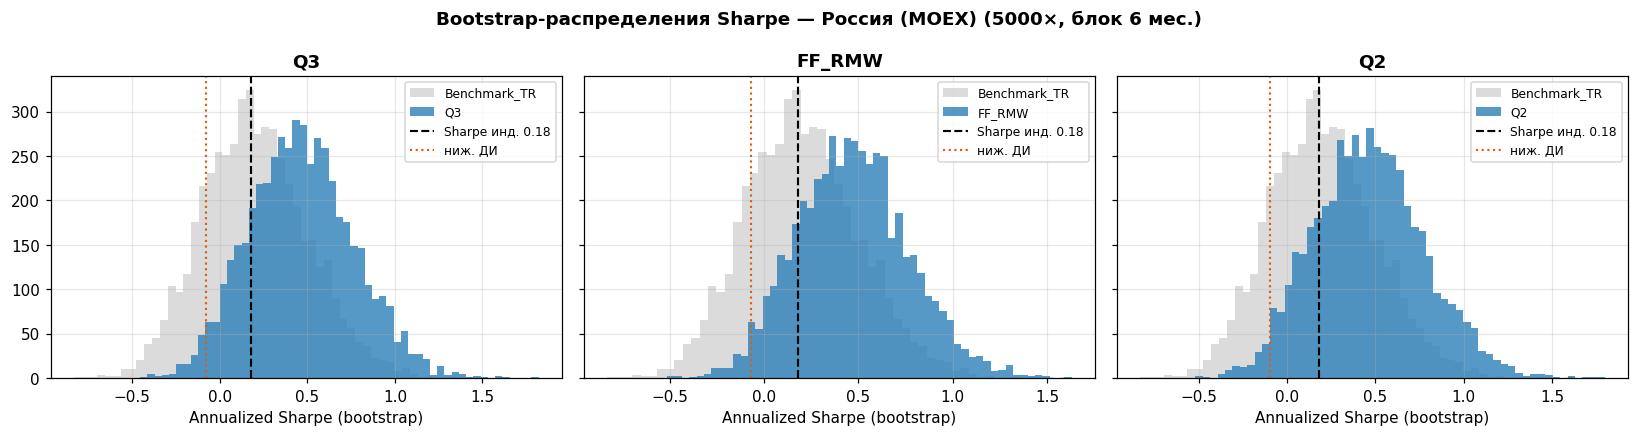

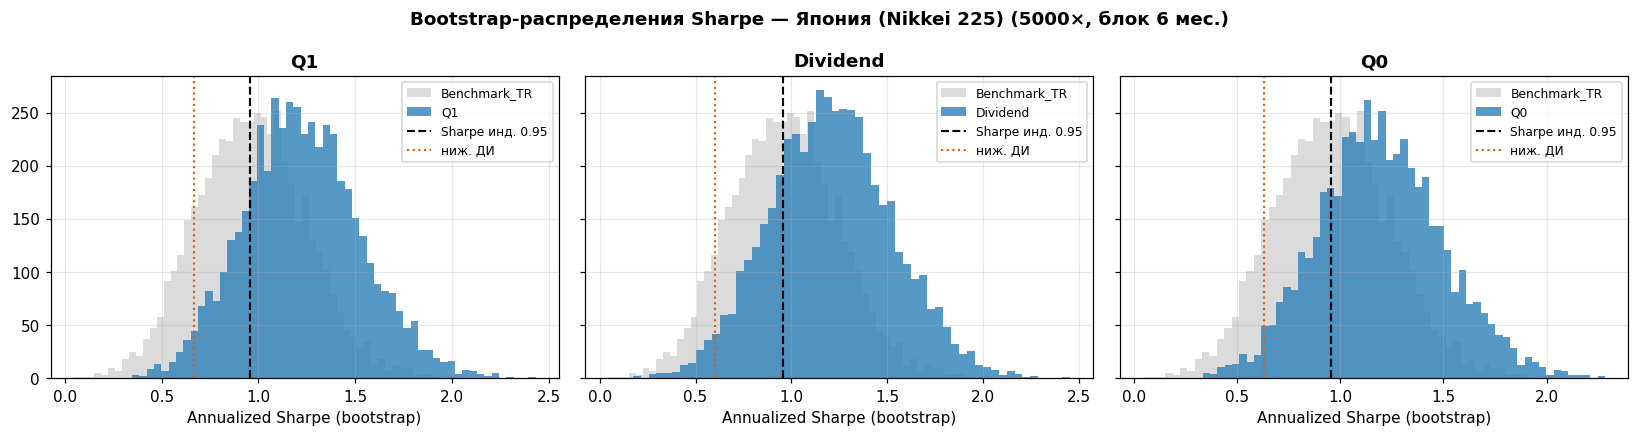

In [7]:
# Гистограммы bootstrap-Sharpe: топ-3 стратегии vs индекс
for name, m in MARKETS.items():
    s4, dists = boot[name]; bench = m['bench']
    top = s4[s4['Ряд']!=bench].sort_values('Sharpe', ascending=False)['Ряд'].head(3).tolist()
    bpt = s4.loc[s4['Ряд']==bench, 'Sharpe'].iloc[0]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, s in zip(axes, top):
        ax.hist(dists[bench], bins=55, color='#cccccc', alpha=0.7, label=bench)
        ax.hist(dists[s], bins=55, color='#2c7fb8', alpha=0.8, label=s)
        ax.axvline(bpt, color='black', ls='--', lw=1.4, label=f'Sharpe инд. {bpt:.2f}')
        ax.axvline(np.nanpercentile(dists[s], 2.5), color='#d95f0e', ls=':', lw=1.4, label='ниж. ДИ')
        ax.set_title(s, fontweight='bold'); ax.set_xlabel('Annualized Sharpe (bootstrap)')
        ax.legend(fontsize=8)
    fig.suptitle(f'Bootstrap-распределения Sharpe — {name} (5000×, блок 6 мес.)', fontweight='bold')
    fig.tight_layout()
    fig.savefig(OUT / f"bootstrap_{'ru' if 'Рос' in name else 'jp'}.png", dpi=150, bbox_inches='tight')
    plt.show()

**Интерпретация.** Если нижняя граница 95%-ДИ Шарпа стратегии выше точечного Шарпа индекса —
превосходство устойчиво даже при осторожной оценке. На обоих рынках этого не достигает никто
(в Японии — из-за высокого Шарпа самого Nikkei). Однако bootstrap p-value показывает: японский
`Q1` обыгрывает индекс в ≈98% репликаций (p≈0.021), `Q0` — в ≈96% (p≈0.039); по России даже
лучшая стратегия проигрывает индексу примерно в 5–6% репликаций неустойчиво (p≈0.055).

## 5. Поправка на множественное тестирование

Дескрипторы Quality отбирались по информационному коэффициенту (IC). Поскольку проверены
десятки дескрипторов, наивный порог значимости даёт ложные открытия. Берём t-статистики
средних IC по **всем** дескрипторам обоих рынков (из `results/quality_research/FULL_RESEARCH_TABLES.xlsx`,
`t = mean_IC / (std_IC/√N_лет)`) и применяем три критерия:

1. **классический** `|t| > 1.96`;
2. **Harvey–Liu–Zhu (2016)** `|t| > 3.0` — рекомендация для факторных исследований;
3. **Benjamini–Hochberg** при FDR = 10% — контроль доли ложных открытий.

In [8]:
def step5_multiple_testing():
    xl = pd.ExcelFile(RESULTS / 'quality_research' / 'FULL_RESEARCH_TABLES.xlsx')
    frames = []
    for label, sheet in [('РФ', 'IC_RF'), ('Япония', 'IC_JP')]:
        d = xl.parse(sheet).copy(); d['Рынок'] = label
        d['SE_IC'] = d['std_IC']/np.sqrt(d['N_years'])
        d['t'] = d['mean_IC']/d['SE_IC']
        frames.append(d[['Рынок', 'descriptor', 'mean_IC', 'N_years', 't']])
    a = pd.concat(frames, ignore_index=True)
    a['p'] = 2*(1-stats.norm.cdf(a['t'].abs()))
    a['|t|>1.96'] = a['t'].abs() > 1.96
    a['HLZ |t|>3.0'] = a['t'].abs() > 3.0
    m = len(a); order = a['p'].values.argsort(); ps = a['p'].values[order]
    below = ps <= (np.arange(1, m+1)/m)*0.10
    k = np.max(np.where(below)[0])+1 if below.any() else 0
    bh = np.zeros(m, bool)
    if k > 0: bh[order[:k]] = True
    a['BH FDR10%'] = bh
    return a.sort_values(['Рынок', 't'], ascending=[True, False]).reset_index(drop=True), k, m

mt, kBH, mDesc = step5_multiple_testing()
print(f"Дескрипторов всего: {mDesc} | классика |t|>1.96: {int(mt['|t|>1.96'].sum())} | "
      f"HLZ |t|>3.0: {int(mt['HLZ |t|>3.0'].sum())} | BH FDR10%: {int(mt['BH FDR10%'].sum())}")
display(mt[mt['|t|>1.96']].round(4))

Дескрипторов всего: 53 | классика |t|>1.96: 10 | HLZ |t|>3.0: 1 | BH FDR10%: 1


,Рынок,descriptor,mean_IC,N_years,t,p,|t|>1.96,HLZ |t|>3.0,BH FDR10%
0,РФ,fcf_yield_pct,0.126,14,3.173,0.002,True,True,True
1,РФ,fcf_to_net_profit,0.056,14,2.402,0.016,True,False,False
2,РФ,ebitda_yoy_pct,0.083,13,2.393,0.017,True,False,False
3,РФ,cash_conversion,0.074,12,2.280,0.023,True,False,False
4,РФ,roa_pct,0.089,14,2.244,0.025,True,False,False
5,РФ,div_yield_pct,0.092,12,2.204,0.028,True,False,False
6,РФ,roe_pct,0.084,14,2.128,0.033,True,False,False
22,РФ,net_debt_to_ebitda,-0.082,14,-2.431,0.015,True,False,False
23,Япония,fcf_yield_pct,0.043,14,2.250,0.024,True,False,False
24,Япония,total_shareholder_yield_pct,0.065,14,2.063,0.039,True,False,False


**Интерпретация.** Классический порог проходят ~10 дескрипторов, но под строгим порогом
Harvey–Liu–Zhu и контролем FDR Benjamini–Hochberg выживает **единственный — FCF yield (Россия)**.
Дивидендная доходность и долговая нагрузка (РФ), shareholder/ FCF yield (Япония) значимы лишь по
наивному критерию. Сила японского Quality обеспечивается **композитом**, а не отдельным
«выжившим» дескриптором.

## 6. Сводка и выводы

In [9]:
def summary_row(name):
    q = quality[name]; s3 = sharpe[name]; s4, _ = boot[name]
    n = len(q); best = s3.iloc[0]
    sig = s3[s3['Значимо 5% (LW)']=='да']['Стратегия'].tolist()
    sb = s4[s4['Ряд']!=MARKETS[name]['bench']].sort_values('p(SR≤индекс)').iloc[0]
    return [
        ['Jarque–Bera', 'Нормальность доходностей',
         f"тяжёлые хвосты у {sum(q['Тяжёлые хвосты']=='да')}/{n}",
         'bootstrap и просадка, не только Sharpe'],
        ['Ljung–Box (²)', 'Кластеризация волатильности',
         f"есть у {sum(q['Кластеризация']=='да')}/{n}", 'обоснованы HAC-ошибки Ньюи–Уэста'],
        ['ADF + KPSS', 'Стационарность', f"стационарны {sum(q['Стационарен']=='да')}/{n}",
         't-тесты и bootstrap корректны'],
        ['Jobson–Korkie/Memmel + Ledoit–Wolf', 'Sharpe выше индекса?',
         f"лучшая — {best['Стратегия']}: {best['Sharpe стратегии']:.2f} vs "
         f"{best['Sharpe индекса']:.2f}, LW p={best['LW p']:.3f}; значимо: {', '.join(sig) if sig else 'нет'}",
         'значимо обыгрывает индекс' if sig else 'различия Sharpe незначимы'],
        ['Block bootstrap (5000×)', 'Надёжность на ~160 набл.',
         f"мин. p(SR≤индекс)={sb['p(SR≤индекс)']:.3f} у {sb['Ряд']}",
         'превосходство устойчиво' if sb['p(SR≤индекс)']<0.05 else 'на коротком окне неустойчиво'],
    ]

for name in MARKETS:
    print(f"\n### {name}")
    display(pd.DataFrame(summary_row(name), columns=['Тест','Что проверяет','Результат','Интерпретация']))

# Сохранение результатов
with pd.ExcelWriter(OUT / 'stat_validation_results.xlsx', engine='openpyxl') as w:
    for name in MARKETS:
        tag = 'RU' if 'Рос' in name else 'JP'
        quality[name].to_excel(w, f'{tag}_качество', index=False)
        sharpe[name].to_excel(w, f'{tag}_Sharpe', index=False)
        boot[name][0].to_excel(w, f'{tag}_bootstrap', index=False)
    mt.to_excel(w, 'Множественное_тестирование', index=False)
print('\nСохранено:', OUT / 'stat_validation_results.xlsx')


### Россия (MOEX)


,Тест,Что проверяет,Результат,Интерпретация
0,Jarque–Bera,Нормальность доходностей,тяжёлые хвосты у 17/17,"bootstrap и просадка, не только Sharpe"
1,Ljung–Box (²),Кластеризация волатильности,есть у 13/17,обоснованы HAC-ошибки Ньюи–Уэста
2,ADF + KPSS,Стационарность,стационарны 17/17,t-тесты и bootstrap корректны
3,Jobson–Korkie/Memmel + Ledoit–Wolf,Sharpe выше индекса?,"лучшая — Q3: 0.46 vs 0.18, LW p=0.076; значимо...",различия Sharpe незначимы
4,Block bootstrap (5000×),Надёжность на ~160 набл.,мин. p(SR≤индекс)=0.055 у Q3,на коротком окне неустойчиво



### Япония (Nikkei 225)


,Тест,Что проверяет,Результат,Интерпретация
0,Jarque–Bera,Нормальность доходностей,тяжёлые хвосты у 7/17,"bootstrap и просадка, не только Sharpe"
1,Ljung–Box (²),Кластеризация волатильности,есть у 7/17,обоснованы HAC-ошибки Ньюи–Уэста
2,ADF + KPSS,Стационарность,стационарны 17/17,t-тесты и bootstrap корректны
3,Jobson–Korkie/Memmel + Ledoit–Wolf,Sharpe выше индекса?,"лучшая — Q1: 1.21 vs 0.95, LW p=0.043; значимо...",значимо обыгрывает индекс
4,Block bootstrap (5000×),Надёжность на ~160 набл.,мин. p(SR≤индекс)=0.021 у Q1,превосходство устойчиво



Сохранено: /Users/dmitrijeremkin/dividend-factor-strategies/results/stat_validation/stat_validation_results.xlsx


### Выводы

1. После строгих проверок **российские факторные стратегии не обыгрывают индекс MCFTR значимо**:
   лучшие (payout/market-specific Quality, FF-profitability; Sharpe ≈ 0.45–0.46 против 0.18 у
   индекса) дают p≈0.08–0.12 и неустойчивы в бутстрэпе.
2. На **японском рынке** значимо обыгрывает Nikkei 225 TR только **profitability-Quality** (`Q1`,
   Sharpe 1.21 против 0.95): LW p≈0.043, bootstrap p≈0.021.
3. Высокий Шарп самого Nikkei (0.95) делает планку «обогнать индекс» жёсткой — нижние границы ДИ
   стратегий лежат ниже точечного Шарпа индекса.
4. Качество данных подтвердило тяжёлые хвосты и кластеризацию волатильности → обоснованы
   HAC-ошибки и бутстрэп; все ряды доходностей стационарны.
5. **Тест на data mining пройден лишь частично:** из 53 дескрипторов классику проходят 10, но
   под порогом Harvey–Liu–Zhu и контролем FDR выживает только **FCF yield (Россия)**.
6. Дивидендная доходность и долговая нагрузка (РФ), shareholder yield (Япония) значимы лишь по
   наивному критерию — это следует отмечать явно.
7. Итог: статистически устойчивое превосходство над индексом подтверждено **только для
   profitability-Quality в Японии**; по России результаты направленно-позитивны, но на горизонте
   2012–2025 статистически неотличимы от индекса.